In [1]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# --- Model Drift Detection (K-S Test) ---
def detect_model_drift(csv_path='../data/model_history.csv'):
    
    df = pd.read_csv(csv_path)
    
    prod_lengths = df['prod_response_len']
    staging_lengths = df['staging_response_len']
    
    ks_stat, p_value = stats.ks_2samp(prod_lengths, staging_lengths)
    
    print("--- MLOps Drift Detection Report ---")
    print(f"K-S Statistic: {ks_stat:.4f}")
    print(f"P-Value:       {p_value:.4e}\n")
    
    if p_value < 0.05:
        print("Status: 🔴 [ALERT] Statistically significant drift detected (p < 0.05).")
        print("Action: Staging model behaves differently than Production.")
    else:
        print("Status: 🟢 [OK] No significant drift detected.")
        print("Action: Staging model behavior is consistent with Production.")
        
    plt.figure(figsize=(8, 4))
    sns.kdeplot(prod_lengths, label='Production', fill=True, color='blue')
    sns.kdeplot(staging_lengths, label='Staging', fill=True, color='orange')
    plt.title('Response Length Distribution: Prod vs Staging')
    plt.xlabel('Response Length (Characters/Tokens)')
    plt.ylabel('Density')
    plt.legend()
    plt.show()

--- MLOps Drift Detection Report ---
K-S Statistic: 0.2780
P-Value:       2.0575e-17

Status: 🔴 [ALERT] Statistically significant drift detected (p < 0.05).
Action: Staging model behaves differently than Production.


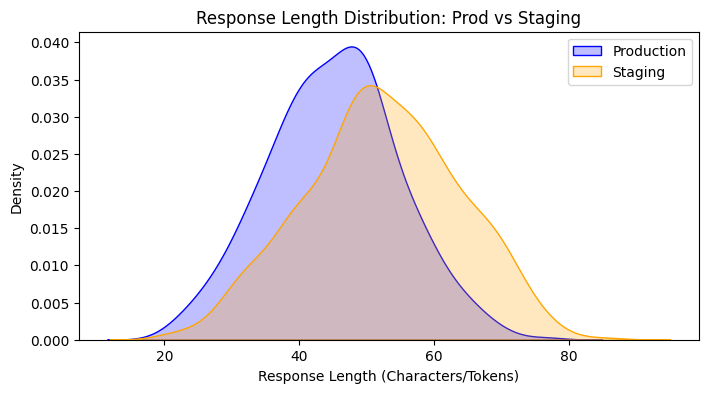

In [3]:
detect_model_drift()

**OBSERVATION - MLOps Drift Detection Interpretation**

The two-sample Kolmogorov-Smirnov (K-S) test was used to compare the "Response Length" distributions of the Production (Champion) and Staging (Challenger) models.

* **Visual Drift (KDE Plot):** The density plot clearly shows a rightward shift. The Staging model (orange) is generating noticeably longer responses on average compared to the Production baseline (blue).
* **Statistical Significance (p < 0.05):** The K-S test yielded an extremely small p-value, confirming that this difference in response length is statistically significant and not due to random sampling variance. 
* **Business Action:** Because significant drift was detected, this triggers an automated MLOps alert. In a CI/CD pipeline, this failure state would block the Staging model from automatically promoting to Production or trigger a retraining pipeline to investigate why the new model has become unexpectedly verbose.